In [1]:
import IPython,ipywidgets as widgets

In [2]:
from cmath import inf,pi,exp
def Segments2Complex(Segs,p0=0.+0.j,scale=1.0,a0=0+1j,tol=0.005,offs=0,loops=1,return_start=False):
  """
  The parameter "tol defines the resolution. It is the maximum allowable
  difference between circular arc segment, and the secant between the
  calculated points on the arc. Smaller values for tol will result in
  more points per segment.
  """
  a=a0
  p=p0*scale
  p-=1j*a*offs
  L=0
  if return_start:
      yield p,a,L,-1 #assuming closed loop: start-point = end-point
  loopcount=0
  while (loops==None) or (loops==inf) or (loopcount<loops):
      loopcount+=1
      for X,(l,da,*_) in enumerate(Segs):
        l=l*scale
        if da!=0:
          r=l/da
          r+=offs
          if r!=0:
            l=r*da
            dl=2*abs(2*r*tol)**0.5
            n=max(int(abs(6*(da/(2*pi)))),int(l//dl)+1)
          else:
            n=1
          dda=exp(1j*da/n)
          dda2=dda**0.5
          v=(2*r*dda2.imag)*dda2*a
        else:
          n=1
          dda=1
          v=l*a
        for i in range(n):
          L+=l/n
          p+=v
          v*=dda
          a*=dda
          yield p,a,L,X

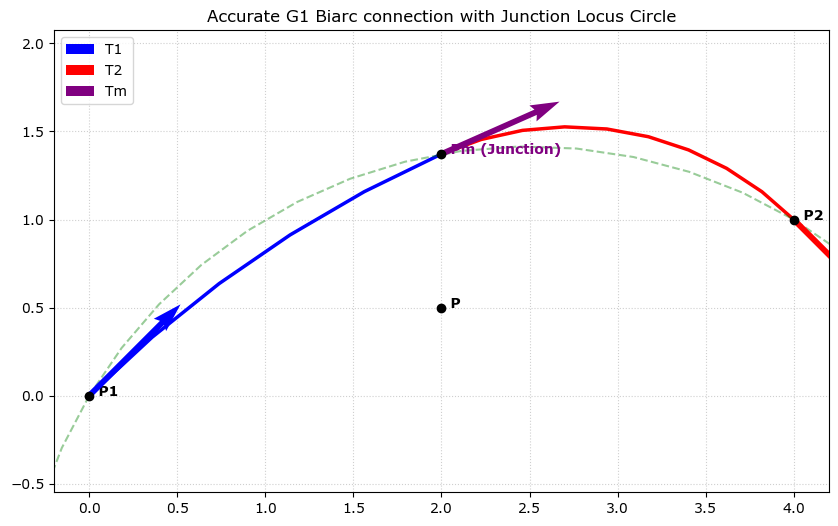

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math
import cmath
rad=(-1)**(1/cmath.pi)
deg=(-1)**(1/180)
inf=cmath.inf
copysign=math.copysign

#def mm(a11,a12,a21,a22, b11,b12,b21,b22):
#  return a11*b11+a12*b21, a11*b12+a12*b22, a21*b11+a22*b21, a21*b12 +a22*b22
matmul=lambda a,b,c,d,e,f,g,h:(a*e + b*g, a*f + b*h, c*e + d*g, c*f + d*h)
mt = lambda x,a=1.0,b=0.0,c=0.0,d=1.0 :(a*x+b)/(c*x+d) if (c*x+d)!=0.0j else inf #mobius transformation
dmt_dx = lambda x,a=1.0,b=0.0,c=0.0,d=1.0 :(a*d-b*c)/(c*x+d)**2 #1st derivative of mobius transformation (rot&scale)
d2mt_dx2 = lambda x,a=1.0,b=0.0,c=0.0,d=1.0 :-2*c*(a*d-b*c)/(c*x+d)**3 #2nd derivative of mobius transformation (curvature)
def get_biarc_mobius_matrices(A: complex, B: complex, v_alpha: complex, v_beta: complex):
    """
    Generates the separate and combined Möbius matrices for the biarc space.
    """
    # 1. World to Normalized Matrix
    M_world_to_norm = np.array([
        [2.0 + 0j, -(A + B)],
        [0.0 + 0j,  B - A]
    ], dtype=complex)
    
    # Calculate the normalized auxiliary vector v_gamma
    # (Note: v_alpha and v_beta must be transformed to normalized space first)
    M_dir = (B - A) / 2
    M_dir_unit = M_dir / abs(M_dir)
    v_alpha_norm = v_alpha / M_dir_unit
    v_beta_norm = v_beta / M_dir_unit
    v_gamma = cmath.sqrt(v_alpha_norm * v_beta_norm.conjugate())
    v_gamma_conj = v_gamma.conjugate()
    
    # 2. Normalized to Rectified Parameter Space Matrix
    M_norm_to_rect = np.array([
        [v_gamma_conj, v_gamma_conj],
        [-1.0 + 0j,    1.0 + 0j]
    ], dtype=complex)
    
    # 3. Combined Forward Matrix via simple 2x2 dot product
    M_combined_forward = M_norm_to_rect @ M_world_to_norm
    
    # 4. Inverse Combined Matrix (Normalized determinant allows easy inversion)
    # Using matrix scaling rule: inv([[a, b], [c, d]]) proportional to [[d, -b], [-c, a]]
    a, b = M_combined_forward[0, 0], M_combined_forward[0, 1]
    c, d = M_combined_forward[1, 0], M_combined_forward[1, 1]
    M_combined_inverse = np.array([
        [d,  -b],
        [-c,  a]
    ], dtype=complex)
    
    return M_combined_forward, M_combined_inverse

def apply_mobius(M: np.ndarray, z: complex) -> complex:
    """Applies a 2x2 Möbius matrix to a complex coordinate z."""
    num = M[0, 0] * z + M[0, 1]
    den = M[1, 0] * z + M[1, 1]
    if den == 0:
        return complex(float('inf'), float('inf'))
    return num / den

def evaluate_p_pure_matrix(z: complex, M_combined: np.ndarray, A: complex, T_A: complex) -> float:
    """
    Computes the parameter p for a world coordinate z using ONLY the combined matrix
    and the start point boundary data. No alpha0 or beta0 tracking needed.
    
    Parameters:
    z          : The real-world tracking point (x + iy)
    M_combined : The 2x2 forward matrix (World -> Rectified Space)
    A          : The real-world start point
    T_A        : The real-world start tangent as a unit complex vector
    """
    # 1. Map tracking point z to the primary rectified space (w)
    num_z = M_combined[0,0] * z + M_combined[0,1]
    den_z = M_combined[1,0] * z + M_combined[1,1]
    
    if abs(den_z) < 1e-12:  # Safe catch at endpoint B (which maps to infinity)
        # Check omega0 sign to determine infinity direction
        return float('inf') if (M_combined[0,0]*A + M_combined[0,1]).imag >= 0 else float('-inf')
        
    w = num_z / den_z
    
    # 2. Extract omega0 directly using the Möbius matrix derivative at start point A
    # f'(A) = det(M) / (c*A + d)^2
    det_M = M_combined[0,0] * M_combined[1,1] - M_combined[0,1] * M_combined[1,0]
    den_deriv = M_combined[1,0] * A + M_combined[1,1]
    
    f_prime_A = det_M / (den_deriv ** 2)
    
    # Transform the tangent vector
    T_rectified = f_prime_A * T_A
    omega0 = cmath.phase(T_rectified)
    
    # Calculate cotangent cleanly
    cot_omega0 = 1.0 / cmath.tan(omega0).real if abs(cmath.tan(omega0).real) > 1e-12 else 0.0

    # 3. Dual Linear Projections based entirely on the transformed space geometry
    if (w.imag * omega0) <= 0:
        # Point belongs to Arc 2 (Linear ray projection in primary w-space)
        return w.real + w.imag * cot_omega0
    else:
        # Point belongs to Arc 1 (Linear ray projection in dual w'-space)
        if abs(w) < 1e-12:  # Point is exactly at start point A (0)
            return 0.0
            
        w_prime = 1.0 / w
        inv_p = w_prime.real + w_prime.imag * cot_omega0
        
        if abs(inv_p) < 1e-12:
            return float('inf')
        return 1.0 / inv_p

def compute_biarc_p_pure_complex(z: complex, v_alpha: complex, v_beta: complex) -> float:
    """
    Computes the biarc parameter p using pure complex geometric projections.
    """
    # Canonical orientation vectors via complex multiplication/roots
    v_omega = cmath.sqrt(v_alpha * v_beta)
    v_gamma = cmath.sqrt(v_alpha * v_beta.conjugate())
    
    # The fundamental complex space factor tracking distance to poles
    W = (1 - z) * (1 + z.conjugate())
    
    # Project tracking vectors onto the boundary tangents
    C = (W * v_gamma).imag
    sin_omega = v_omega.imag

    if sin_omega * C <= 0:
        num = (abs(z + 1) ** 2) * sin_omega
        den = (W * v_alpha).imag
        return num / den
    else:
        num = (W.conjugate() * v_beta).imag
        den = (abs(z - 1) ** 2) * sin_omega
        return num / den

def compute_biarc_p(P: complex, w0: float) -> float:
    """
    Computes the biarc family parameter p for a given point P (x + iy) 
    and lens half-width angle w0 according to Equation (33).
    """
    # 1. Phase angle of the lens as a complex unit vector
    E2 = rad**(2* w0)
    
    # 2. Conformal Möbius mapping to the W-plane
    W = (P - 1) / (P + 1)
    
    # 3. Branch execution based on the sign of the imaginary part
    if P.imag >= 0:
        p_complex = (1 - E2) / (E2 * W - W.conjugate())
    else:
        p_complex = (E2 * (1 / W) - (1 / W.conjugate())) / (1 - E2)
        
    # The result is strictly a real number; extract the real part
    return p_complex.real
    
import cmath

def calculate_biarc_geometry_complex(p: float, Ta: complex, Tb: complex):
    """
    Calculates the biarc geometry using purely complex vector math.
    
    Inputs:
        p: family parameter (float)
        Ta: complex unit vector of the start tangent (e^(i*alpha0))
        Tb: complex unit vector of the end tangent (e^(i*beta0))
    """
    # --- 1. Compute the Complex Junction Point J ---
    # In complex terms, Kurnosenko's lens bisector phasor is sqrt(Ta * Tb.conjugate())
    # F scales perfectly into a clean inner product variant:
    F = p**2 + p * (Ta * Tb.conjugate() + 1).real + 1.0
    
    if abs(F) < 1e-12:
        raise ValueError("Parameter p matches a discontinuous biarc boundary.")
    
    # Elegant complex projection mapping the poles A(-1) and B(1) to J
    J = ((p**2 - 1.0) + 1j * p * (Ta - Tb)) / F

    # --- 2. Compute the Tangent Phasor at the Junction (Tj) ---
    # Using complex square roots avoids half-angle tan arithmetic entirely
    num = p * cmath.sqrt(Ta) + cmath.sqrt(Tb)
    
    # Squaring the normalized numerator naturally recovers the full exit tangent
    Tj = -(num / abs(num))**2
    
    # --- 3. Compute Arc Heading Changes (theta1, theta2) ---
    # Relative rotations are just the phase angles of the phasor quotients
    theta1 = cmath.phase(Tj / Ta)
    theta2 = cmath.phase(Tb / Tj)
    
    return {
        "junction": J,
        "tangent_at_junction": Tj,       # Returned as a complex unit vector
        "arc1_heading_change": theta1,    # In radians, naturally in (-pi, pi]
        "arc2_heading_change": theta2     # In radians, naturally in (-pi, pi]
    }
    
def find_arc_center_radius(p_start, t_start, p_end):
        # Center is intersection of tangent normal and chord perpendicular 
        t_start/=abs(t_start)
        chord = p_end - p_start
        l_chord = abs(chord)
        e_chord = chord/l_chord
        phi=e_chord/t_start
        r=0.5*l_chord/phi.imag
        #print(f'{phi=}, {l_chord=}')
        return p_start+r*t_start*1j, r

def compute_biarc_original_hybrid(p1, t1, p2, t2):
    #p1,p2,t1,t2 = (complex(*p) for p in (p1,p2,t1,t2))
    t1/= abs(t1)
    t2/= abs(t2)

    v = p2 - p1
    v_dot_t1 = (v*t1.conjugate()).real
    v_dot_t2 = (v*t2.conjugate()).real
    t1_dot_t2 = (t1*t2.conjugate()).real
    
    # 1. Revert to the original symmetric weight formula
    a = 2.0 * (1.0 - t1_dot_t2)
    b = 2.0 * (v_dot_t1 + v_dot_t2)
    c = -(v*v.conjugate()).real
    
    discriminant = b**2 - 4*a*c
    d1 = (-b + np.sqrt(discriminant)) / (2.0 * a)
    d2 = d1

    # Exact original formula for the junction point
    pm = p1 + d1 * t1 + (p2 - p1 - d1*t1 - d2*t2) / 2.0 
    

    # 2. Independently compute Arc 1 and Arc 2 properties from Pm
    c1, r1 = find_arc_center_radius(p1, t1, pm)
    c2, r2 = find_arc_center_radius(p2, -t2, pm) # Path arriving at P2 along t2
    
    # Calculate the continuous joint tangent at Pm
    v_pm = pm - c1
    tm= v_pm/r1*1j
     
    return p1, pm, p2, c1, r1, c2, r2, t1, t2, tm

def get_arc_points(center, p_start, p_end, t_start, num_points=100):
    
    v_start = p_start - center
    v_end = p_end - center
    phi=v_end/v_start
    dphi=phi**(1/num_points)
    #print (f'{dphi=}')
    v=v_start
    yield center+v_start
    for i in range(num_points):
        v_start*=dphi
        yield center+v_start
        
    
def find_circle(p1: complex, p2: complex, p3: complex):
    # Calculate the cyclic differences
    d1 = p2 - p3
    d2 = p3 - p1
    d3 = p1 - p2
    pd1=p1.conjugate() * d1
    pd2=p2.conjugate() * d2
    pd3=p3.conjugate() * d3
    # Elegant complex algebraic numerator and denominator
    numerator = p1*pd1 + p2*pd2 + p3*pd3
    denominator = pd1 + pd2 + pd3
    
    # If the denominator is 0 (or close to it), the points are collinear
    if abs(denominator) < 1e-12:
        center = numerator*cmath.inf
    else:   
        center = numerator / denominator
    radius = abs(center - p1)
    
    return center, radius


def find_locus_circle(p1, pm, p2):
    p1,pm,p2 = (complex(*p) for p in (p1,pm,p2))
    """Computes the circle passing through the three points P1, Pm, and P2."""
    center,radius=find_circle(p1,pm,p2)
    return [center.real,center.imag],radius

def arc_from_chord(p1,t1,p2):
    ch1=p2-p1#chord
    ph1=ch1/t1 
    ph1/=abs(ph1)
    sinph1=ph1.imag
    ang1=cmath.polar(ph1)[1]#angle between arc and chord ]-pi...pi] 
    l1=abs(ch1)*(1 if sinph1==0 else ang1/sinph1) #convert 
    return l1,2*ang1
    
def compute_biarc(p1,t1,p2,t2,p):
    m=(2,-(p1+p2),0,p2-p1) # rotate&scale p1->-1, p2->+1
    
    phl=(t2/t1)**0.5 #correct sign? may be use both (forward and backward)
    phl/=abs(phl)
    
    ml=(phl+1,phl-1,phl-1,phl+1)# junction locus circle->real axis
    mn=matmul(*ml,*m)#normalization matrix junction points on real axis
    pn=mt(p,*mtot)

    
    chl=p2-p1 #junction locus circle
    tl=chl/phl
    tl/=abs(tl)
    sinphl=phl.imag
    angl=cmath.polar(phl)[1]
    ll=abs(chl)*(1 if sinphl==0 else angl/sinphl)
    
    l1,ang1=arc_from_chord(p1,t1,pm)
    l2,ang2=arc_from_chord(pm,tm,p2)
    return pj,tj,l1,ang1,l2,ang2,tl,ll,angl
    
    

# --- Run & Plot ---
def plot_biarc(A,At,B,Bt,P,m=(1.0, 0.0, 0.0, 1.0)):
    #A,B= (mt(x,*m) for x in (A,B))
    #At,Bt = (x*dmt_dx(x,*m) for x in (At,Bt))
    p1, pm, p2, c1, r1, c2, r2, t1, t2, tm = compute_biarc_original_hybrid(A,At,B,Bt)

    
    ch1=pm-p1#chord
    ph1=ch1/t1 
    ph1/=abs(ph1)
    sinph1=ph1.imag
    ang1=cmath.polar(ph1)[1]#angle between arc and chord ]-pi...pi] 
    l1=abs(ch1)*(1 if sinph1==0 else ang1/sinph1) #convert 
    arc1xy=zip(*([x.real,x.imag] for p,*_ in Segments2Complex([[l1,-2*ang1]],p0=pm,a0=-tm,scale=1.0,return_start=True) for x in (mt(p,*m),)))
  
    ch2=p2-pm
    ph2=ch2/tm
    ph2/=abs(ph2)
    sinph2=ph2.imag
    ang2=cmath.polar(ph2)[1]
    l2=abs(ch2)*(1 if sinph2==0 else ang2/sinph2)
    arc2xy=zip(*([x.real,x.imag] for p,*_ in Segments2Complex([[l2,2*ang2]],p0=pm,a0=tm,scale=1.0,return_start=True) for x in (mt(p,*m),)))
    
    chl=p2-p1 #junction locus circle
    phl=(t2/t1)**0.5 #correct sign? may be use both (forward and backward)
    phl/=abs(phl)
    tl=chl/phl
    tl/=abs(tl)
    sinphl=phl.imag
    angl=cmath.polar(phl)[1]
    ll=abs(chl)*(1 if sinphl==0 else angl/sinphl)
    arclxy1=zip(*([x.real,x.imag] for p,*_ in Segments2Complex([[ll,2*angl]],p0=p1,a0=tl,scale=1.0,return_start=True) for x in (mt(p,*m),)))
    arclxy2=zip(*([x.real,x.imag] for p,*_ in Segments2Complex([[ll/angl*(copysign(pi,angl)-angl),-2*(copysign(pi,angl)-angl)]],p0=p1,a0=-tl,scale=1.0,return_start=True) for x in (mt(p,*m),)))
    
    t1,tm,t2=(dmt_dx(p,*m)*t for p,t in ((p1,t1),(pm,tm),(p2,t2)))
    p1,pm,p2,P=(mt(p,*m) for p in (p1,pm,p2,P))
    
    # Plotting
    plt.close()
    fig1=plt.figure(figsize=(10, 6))
 
    plt.scatter(*zip(*((x.real,x.imag) for x in [p1, pm, p2, P])), color='black', zorder=5)
    plt.text(p1.real, p1.imag, '  P1', fontdict={'weight': 'bold'})
    plt.text(pm.real, pm.imag, '  Pm (Junction)', fontdict={'weight': 'bold', 'color': 'purple'})
    plt.text(p2.real, p2.imag, '  P2', fontdict={'weight': 'bold'})
    plt.text(P.real, P.imag, '  P', fontdict={'weight': 'bold'})
    

    # Render tangent vectors
    plt.quiver(p1.real,p1.imag, t1.real, t1.imag, color='blue', scale=6, zorder=4, label='T1')
    plt.quiver(p2.real,p2.imag, t2.real, t2.imag, color='red', scale=6, zorder=4, label='T2')
    plt.quiver(pm.real,pm.imag, tm.real, tm.imag, color='purple', scale=6, zorder=4, label='Tm')
    plt.axis('equal')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.plot(*arc1xy, 'b-', linewidth=2.5, label='Arc 1 (P1 to Pm)')
    plt.plot(*arc2xy, 'r-', linewidth=2.5, label='Arc 2 (Pm to P2)')
    xl=plt.xlim()
    yl=plt.ylim()

    plt.plot(*arclxy1, 'g--', alpha=0.4, label='Junction Locus Circle')
    plt.plot(*arclxy2, 'g--', alpha=0.4)
    plt.xlim(xl)
    plt.ylim(yl)
    plt.title("Accurate G1 Biarc connection with Junction Locus Circle")
    plt.close()
    return fig1
IPython.display.display(plot_biarc(0.0,deg**45,4+1j,deg**-45,2.0+1j*0.5))

In [31]:
from ipywidgets import HBox,VBox,FloatSlider

state=dict(Ax=0.0,Ay=0.0,At=45.0,Bx=4.0,By=1.0,Bt=-45.0,Px=2.0,Py=0.5)

output1,output2,output3,output4=(widgets.Output() for _ in range(4))

def update_outputs():
        A=state['Ax']+1j*state['Ay']
        At=deg**state['At']
        B=state['Bx']+1j*state['By']
        Bt=deg**state['Bt']
        P=state['Px']+1j*state['Py']
        output1.clear_output(wait=True)
        with output1:
            IPython.display.display(plot_biarc(A,At,B,Bt,P))
        output2.clear_output(wait=True)
        with output2:
            print(f"{A=:.3}, {At=:.3}, {B=:.3}, {Bt=:.3}, {P=:.3}")
        output3.clear_output(wait=True)
        m=(2,-(A+B),0,B-A)
        with output3:
            IPython.display.display(plot_biarc(A,At,B,Bt,P,m))
        output4.clear_output(wait=True)
        with output4:
            m=(2,-(A+B),0,B-A)
            v_gamma_conj = (Bt/At)**0.5
            v_gamma_conj/=abs(v_gamma_conj)
            # 2. Normalized to Rectified Parameter Space Matrix
            M_norm_to_rect = (v_gamma_conj +1, v_gamma_conj-1,  v_gamma_conj-1,  v_gamma_conj+1)
            mtot=matmul(*M_norm_to_rect,*m)
            print(f"{mtot=}")
            IPython.display.display(plot_biarc(A,At,B,Bt,P,mtot))

update_outputs()
def ChangeHandler(change):
    #with output2:
    #    print(change)
    if change['type']=='change' and change['name']=='value':
        state[change['owner'].description]=change['new']
        update_outputs()
        
Ax=FloatSlider(value=state['Ax'],min=-5,max=5, description='Ax');Ax.observe(ChangeHandler)
Ay=FloatSlider(value=state['Ay'], min=-5,max=5, description='Ay',orientation='vertical');Ay.observe(ChangeHandler)
At=FloatSlider(value=state['At'],min=-180,max=180 , description='At');At.observe(ChangeHandler)
Px=FloatSlider(value=state['Px'],min=-5,max=5, description='Px');Px.observe(ChangeHandler)
Py=FloatSlider(value=state['Px'],min=-5,max=5, description='Py',orientation='vertical');Py.observe(ChangeHandler)
Bx=FloatSlider(value=state['Bx'],min=-5,max=5, description='Bx');Bx.observe(ChangeHandler)
By=FloatSlider(value=state['By'], min=-5,max=5, description='By',orientation='vertical');By.observe(ChangeHandler)
Bt=FloatSlider(value=state['Bt'], min=-180,max=180 , description='Bt');Bt.observe(ChangeHandler)
VBox([HBox( [output1,HBox([Ay,By,Py])]),HBox([VBox([Ax,At]),VBox([Px]),VBox([Bx,Bt])]),output2]) 

In [28]:
output3

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 1000x600 with 1 Axes>', '…

In [29]:
output4

Output(outputs=({'name': 'stdout', 'text': 'mtot=((3.414213562373095-1.414213562373095j), (-8-2j), (-0.5857864…

In [7]:
def find_biarc_junction(P):
    """
    Given an arbitrary complex point P, returns the junction point x_0 
    on the real axis (-1 < x_0 < 1) that creates a smooth biarc through P.
    """
    # 1. Map P to the straight-line plane W
    W_P = (P + 1) / (1 - P)
    
    # 2. Calculate the mapped junction point using the geometry at infinity
    W_x0 = W_P.real + abs(W_P)
    
    # 3. Map back to the world real axis
    x_0 = (W_x0 - 1) / (W_x0 + 1)
    
    return x_0
